# TechOps Intelligence Platform
## Notebook 01 — Data Collection & Exploratory Data Analysis

**Phase:** 1 — Data Understanding  
**Goal:** Load all data sources, understand structure,
          quality, and distribution before any processing

### Data Sources
- IT Incidents (ServiceNow ITSM — Kaggle)
- Support Tickets (Kaggle)
- Cybersecurity Incidents (Kaggle)
- System Logs (LogHub — Apache, Linux, HDFS)
- System Metrics (Kaggle + Westermo)
- Postmortems (Qwen-generated from real patterns)
- Scanned Documents (RVL-CDIP HuggingFace)
- PDF Documents (SRE Book + AWS)

In [43]:
import os
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()

# All paths from project root
RAW_TEXT    = PROJECT_ROOT / "data/raw/text"
RAW_TABULAR = PROJECT_ROOT / "data/raw/tabular"
RAW_IMAGES  = PROJECT_ROOT / "data/raw/images"
RAW_PDFS    = PROJECT_ROOT / "data/raw/pdfs"
PROCESSED   = PROJECT_ROOT / "data/processed"

PROCESSED.mkdir(parents=True, exist_ok=True)


### 1. IT Incident Data (ServiceNow ITSM)
#### Primary training data for the classifier
#### 141,712 real enterprise IT events

In [44]:
# ─────────────────────────────────────────
# LOAD SERVICENOW ITSM INCIDENTS
# ─────────────────────────────────────────
incident_file = RAW_TEXT / "incidents/incident_event_log_dataset.csv"

df_incidents = pd.read_csv(incident_file, low_memory=False)

print(f"=== ServiceNow ITSM Dataset ===")
print(f"Shape    : {df_incidents.shape}")
print(f"Rows     : {df_incidents.shape[0]:,}")
print(f"Columns  : {df_incidents.shape[1]}")
print(f"\nColumn names:\n{df_incidents.columns.tolist()}")
print(f"\nData types:\n{df_incidents.dtypes}")
print(f"\nFirst 3 rows:\n{df_incidents.head(3)}")

=== ServiceNow ITSM Dataset ===
Shape    : (141712, 37)
Rows     : 141,712
Columns  : 37

Column names:
['number', 'incident_state', 'active', 'reassignment_count', 'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by', 'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by', 'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory', 'symptom', 'cmdb_ci', 'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to', 'knowledge', 'u_priority_confirmation', 'notify', 'problem_id', 'change', 'vendor', 'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at', 'isParent']

Data types:
number                       str
incident_state               str
active                      bool
reassignment_count         int64
reopen_count               int64
sys_mod_count              int64
made_sla                    bool
caller_id                    str
opened_by                    str
opened_at                    str
sys_created_by          

=== Missing + Masked Values ===

Columns with '?' masked values:
caused_by           141689
vendor              141468
cmdb_ci             141267
change              140721
problem_id          139417
sys_created_by       53076
sys_created_at       53076
symptom              32964
assigned_to          27496
assignment_group     14213
opened_by             4835
resolved_at           3141
closed_code            714
resolved_by            226
subcategory            111
category                78
location                76
caller_id               29
dtype: int64

Columns with NaN:
Series([], dtype: int64)

=== Duplicate Analysis ===
Total rows      : 141,712
Unique incidents: 24,918
Duplicate rows  : 116,794
Avg states/inc  : 5.7

=== Priority Distribution ===
priority
3 - Moderate    132452
4 - Low           4030
2 - High          2972
1 - Critical      2258
Name: count, dtype: int64

=== Category Distribution (Top 10) ===
category
Category 26    18453
Category 42    15977
Category 53    1

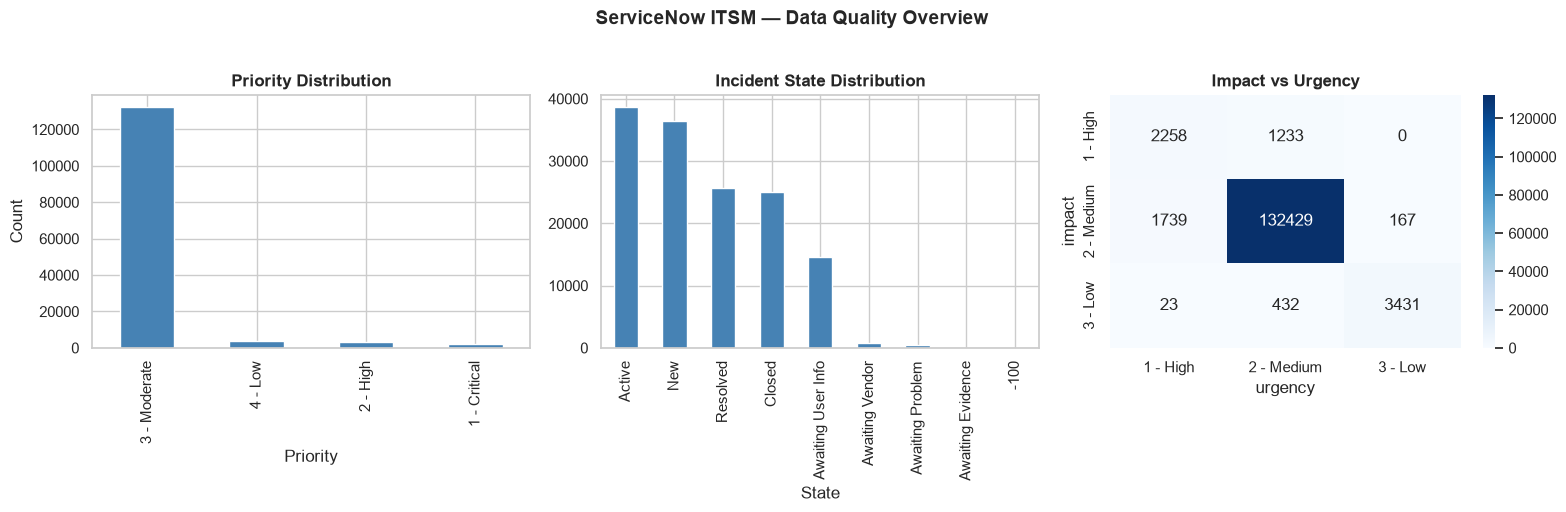

✓ EDA plot saved


In [45]:
# ─────────────────────────────────────────
# SERVICENOW ITSM — QUALITY ANALYSIS
# ─────────────────────────────────────────

# ── 1. Missing / Masked Values ───────────
print("=== Missing + Masked Values ===\n")

# Count "?" as missing
masked = (df_incidents == '?').sum()
masked = masked[masked > 0].sort_values(ascending=False)
print("Columns with '?' masked values:")
print(masked)

# Standard nulls
nulls = df_incidents.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print(f"\nColumns with NaN:")
print(nulls)

# ── 2. Duplicate Incidents ────────────────
print(f"\n=== Duplicate Analysis ===")
total_rows    = len(df_incidents)
unique_inc    = df_incidents['number'].nunique()
duplicates    = total_rows - unique_inc
print(f"Total rows      : {total_rows:,}")
print(f"Unique incidents: {unique_inc:,}")
print(f"Duplicate rows  : {duplicates:,}")
print(f"Avg states/inc  : {total_rows/unique_inc:.1f}")

# ── 3. Priority Distribution ──────────────
print(f"\n=== Priority Distribution ===")
print(df_incidents['priority'].value_counts())

# ── 4. Category Distribution ──────────────
print(f"\n=== Category Distribution (Top 10) ===")
print(df_incidents['category'].value_counts().head(10))

# ── 5. Incident State Distribution ───────
print(f"\n=== Incident State Distribution ===")
print(df_incidents['incident_state'].value_counts())

# ── 6. SLA Compliance ────────────────────
print(f"\n=== SLA Compliance ===")
sla_rate = df_incidents['made_sla'].mean() * 100
print(f"SLA met rate: {sla_rate:.1f}%")

# ── 7. Visualise Priority ────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Priority
df_incidents['priority'].value_counts().plot(
    kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Priority Distribution',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Priority')
axes[0].set_ylabel('Count')

# Incident State
df_incidents['incident_state'].value_counts().plot(
    kind='bar', ax=axes[1],
    color='steelblue', edgecolor='white'
)
axes[1].set_title('Incident State Distribution',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('State')

# Impact vs Urgency heatmap
pivot = df_incidents.groupby(
    ['impact', 'urgency']
).size().unstack(fill_value=0)

sns.heatmap(
    pivot, annot=True, fmt='d',
    cmap='Blues', ax=axes[2]
)
axes[2].set_title('Impact vs Urgency',
                   fontsize=12, fontweight='bold')

plt.suptitle(
    'ServiceNow ITSM — Data Quality Overview',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'notebooks/incidents_eda.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✓ EDA plot saved")

In [49]:
# ─────────────────────────────────────────
# SERVICENOW ITSM — CLEANING
# ─────────────────────────────────────────

# ── Step 1: Drop Heavily Masked Columns ──
drop_cols = [
    'caused_by', 'vendor', 'cmdb_ci',
    'change', 'problem_id',
    'sys_created_by', 'sys_created_at',
    'sys_updated_by', 'sys_updated_at',
    'opened_by', 'resolved_by',
    'caller_id', 'notify',
    'knowledge', 'u_priority_confirmation',
    'isParent', 'active'
]

df_clean = df_incidents.drop(
    columns=[c for c in drop_cols
             if c in df_incidents.columns]
)
print(f"Columns after drop: {df_clean.shape[1]}")
print(f"Remaining: {df_clean.columns.tolist()}")

# ── Step 2: Replace "?" with NaN ─────────
df_clean = df_clean.replace('?', pd.NA)
print(f"\nAfter replacing '?': {df_clean.isnull().sum().sum()} nulls")

# ── Step 3: Deduplicate ───────────────────
# Priority order for keeping state
state_priority = {
    'Closed'            : 1,
    'Resolved'          : 2,
    'Active'            : 3,
    'Awaiting User Info': 4,
    'Awaiting Vendor'   : 5,
    'Awaiting Problem'  : 6,
    'Awaiting Evidence' : 7,
    'New'               : 8,
    '-100'              : 9
}

df_clean['state_rank'] = df_clean['incident_state'].map(
    state_priority
).fillna(9)

# Keep one row per incident — best state
df_dedup = df_clean.sort_values(
    ['number', 'state_rank']
).groupby('number').first().reset_index()

df_dedup = df_dedup.drop(columns=['state_rank'])

print(f"\n=== After Deduplication ===")
print(f"Before : {len(df_clean):,} rows")
print(f"After  : {len(df_dedup):,} rows")
print(f"Unique incidents: {df_dedup['number'].nunique():,}")

# ── Step 4: Clean Priority Column ────────
priority_map = {
    '1 - Critical' : 'P1',
    '2 - High'     : 'P2',
    '3 - Moderate' : 'P3',
    '4 - Low'      : 'P4'
}
df_dedup['priority_clean'] = df_dedup['priority'].map(
    priority_map
)

print(f"\n=== Cleaned Priority Distribution ===")
print(df_dedup['priority_clean'].value_counts())

# ── Step 5: Clean Impact + Urgency ───────
impact_map = {
    '1 - High'  : 'High',
    '2 - Medium': 'Medium',
    '3 - Low'   : 'Low'
}
urgency_map = {
    '1 - High'  : 'High',
    '2 - Medium': 'Medium',
    '3 - Low'   : 'Low'
}
df_dedup['impact_clean']  = df_dedup['impact'].map(impact_map)
df_dedup['urgency_clean'] = df_dedup['urgency'].map(urgency_map)

# ── Step 6: Calculate MTTR ───────────────
df_dedup['opened_at']   = pd.to_datetime(
    df_dedup['opened_at'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)
df_dedup['resolved_at'] = pd.to_datetime(
    df_dedup['resolved_at'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

df_dedup['mttr_minutes'] = (
    df_dedup['resolved_at'] - df_dedup['opened_at']
).dt.total_seconds() / 60

resolved_mask = df_dedup['mttr_minutes'].notna()
print(f"\n=== MTTR Analysis ===")
print(f"Incidents with MTTR : {resolved_mask.sum():,}")
print(f"Mean MTTR           : {df_dedup.loc[resolved_mask, 'mttr_minutes'].mean():.0f} mins")
print(f"Median MTTR         : {df_dedup.loc[resolved_mask, 'mttr_minutes'].median():.0f} mins")
print(f"Max MTTR            : {df_dedup.loc[resolved_mask, 'mttr_minutes'].max():.0f} mins")

# ── Step 7: Keep Useful Columns ──────────
final_cols = [
    'number', 'incident_state',
    'category', 'subcategory', 'symptom',
    'impact_clean', 'urgency_clean',
    'priority_clean', 'contact_type',
    'reassignment_count', 'reopen_count',
    'made_sla', 'mttr_minutes',
    'assignment_group'
]

df_final = df_dedup[[
    c for c in final_cols
    if c in df_dedup.columns
]]

print(f"\n=== Final Dataset ===")
print(f"Shape  : {df_final.shape}")
print(f"Sample :\n{df_final.head(3)}")

# ── Step 8: Save ─────────────────────────
df_final.to_csv(
    PROCESSED / "incidents_clean.csv",
    index=False
)
print(f"\n✓ Saved → data/processed/incidents_clean.csv")
print(f"  Rows    : {len(df_final):,}")
print(f"  Columns : {df_final.shape[1]}")

Columns after drop: 20
Remaining: ['number', 'incident_state', 'reassignment_count', 'reopen_count', 'sys_mod_count', 'made_sla', 'opened_at', 'contact_type', 'location', 'category', 'subcategory', 'symptom', 'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to', 'closed_code', 'resolved_at', 'closed_at']

After replacing '?': 78793 nulls

=== After Deduplication ===
Before : 141,712 rows
After  : 24,918 rows
Unique incidents: 24,918

=== Cleaned Priority Distribution ===
priority_clean
P3    23466
P4      774
P2      408
P1      270
Name: count, dtype: int64

=== MTTR Analysis ===
Incidents with MTTR : 23,362
Mean MTTR           : 10690 mins
Median MTTR         : 1326 mins
Max MTTR            : 484210 mins

=== Final Dataset ===
Shape  : (24918, 14)
Sample :
       number incident_state     category      subcategory      symptom  \
0  INC0000045         Closed  Category 55  Subcategory 170   Symptom 72   
1  INC0000047         Closed  Category 40  Subcategory 215  Symptom

In [46]:
df_cyber = pd.read_csv(
    RAW_TEXT / "incidents/cybersecurity_synthesized_data.csv",
    low_memory=False
)
print(f"Shape: {df_cyber.shape}")
print(f"\nColumns: {df_cyber.columns.tolist()}")
print(f"\nSample:\n{df_cyber.head(2)}")
print(f"\nNull counts:\n{df_cyber.isnull().sum()}")

Shape: (100000, 15)

Columns: ['attack_type', 'target_system', 'outcome', 'timestamp', 'attacker_ip', 'target_ip', 'data_compromised_GB', 'attack_duration_min', 'security_tools_used', 'user_role', 'location', 'attack_severity', 'industry', 'response_time_min', 'mitigation_method']

Sample:
  attack_type  target_system  outcome                   timestamp  \
0    Phishing  Cloud Service  Failure  2024-04-03 11:13:15.083419   
1        DDoS   Email Server  Success  2024-02-03 20:51:56.083463   

       attacker_ip      target_ip  data_compromised_GB  attack_duration_min  \
0      21.166.79.4    23.20.50.78                15.31                  300   
1  187.180.150.169  34.160.58.218                65.05                  242   

  security_tools_used user_role   location  attack_severity industry  \
0            Firewall  Employee  Australia                2   Energy   
1  Endpoint Detection     Admin     Brazil               10   Retail   

   response_time_min  mitigation_method  
0   

In [48]:
# ─────────────────────────────────────────
# CYBERSECURITY DATASET — CLEANING
# ─────────────────────────────────────────
df_cyber = pd.read_csv(
    RAW_TEXT / "incidents/cybersecurity_synthesized_data.csv",
    low_memory=False
)

# ── Step 1: Map severity 1-10 → P1-P4 ────
def map_severity_to_priority(score):
    if score >= 8:   return 'P1'
    elif score >= 6: return 'P2'
    elif score >= 4: return 'P3'
    else:            return 'P4'

df_cyber['priority_clean'] = df_cyber[
    'attack_severity'
].apply(map_severity_to_priority)

print("=== Cybersecurity Priority Distribution ===")
print(df_cyber['priority_clean'].value_counts())

# ── Step 2: Map to our category system ───
attack_to_category = {
    'DDoS'              : 'network',
    'Phishing'          : 'security',
    'Ransomware'        : 'security',
    'SQL Injection'     : 'database',
    'Man-in-the-Middle' : 'network',
    'Insider Threat'    : 'security',
    'Zero-Day Exploit'  : 'security',
    'Brute Force'       : 'security'
}

df_cyber['category'] = df_cyber['attack_type'].map(
    attack_to_category
).fillna('security')

print("\n=== Attack Type Distribution ===")
print(df_cyber['attack_type'].value_counts())

print("\n=== Mapped Category Distribution ===")
print(df_cyber['category'].value_counts())

# ── Step 3: Create text description ──────
# Combine columns into text for NLP use
df_cyber['incident_text'] = (
    "Security incident: " + df_cyber['attack_type'] +
    " targeting " + df_cyber['target_system'] +
    " in " + df_cyber['industry'] + " industry. " +
    "Outcome: " + df_cyber['outcome'] + ". " +
    "Mitigated by: " + df_cyber['mitigation_method'] + "."
)

print("\n=== Sample Generated Text ===")
print(df_cyber['incident_text'].iloc[0])
print(df_cyber['incident_text'].iloc[1])

# ── Step 4: Keep Useful Columns ──────────
df_cyber_clean = df_cyber[[
    'attack_type', 'target_system',
    'outcome', 'attack_severity',
    'priority_clean', 'category',
    'industry', 'response_time_min',
    'mitigation_method', 'incident_text'
]].copy()

# ── Step 5: Sample 10K rows ──────────────
# 100K is too many for classifier training
# balanced sample is better
df_cyber_sample = pd.concat(
    [
        group.sample(
            n=min(len(group), 2500),
            random_state=42
        )
        for _, group in df_cyber_clean.groupby('priority_clean')
    ],
    ignore_index=True
)
# ── Step 6: Save ─────────────────────────
df_cyber_sample.to_csv(
    PROCESSED / "cybersecurity_clean.csv",
    index=False
)
print(f"\n✓ Saved → data/processed/cybersecurity_clean.csv")

=== Cybersecurity Priority Distribution ===
priority_clean
P4    29963
P1    29871
P2    20087
P3    20079
Name: count, dtype: int64

=== Attack Type Distribution ===
attack_type
Brute Force             12605
DDoS                    12557
Zero-Day Exploit        12555
Ransomware              12499
Malware                 12469
SQL Injection           12463
Phishing                12441
Cross-Site Scripting    12411
Name: count, dtype: int64

=== Mapped Category Distribution ===
category
security    74980
network     12557
database    12463
Name: count, dtype: int64

=== Sample Generated Text ===
Security incident: Phishing targeting Cloud Service in Energy industry. Outcome: Failure. Mitigated by: Containment.
Security incident: DDoS targeting Email Server in Retail industry. Outcome: Success. Mitigated by: Reset Credentials.

✓ Saved → data/processed/cybersecurity_clean.csv
